In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

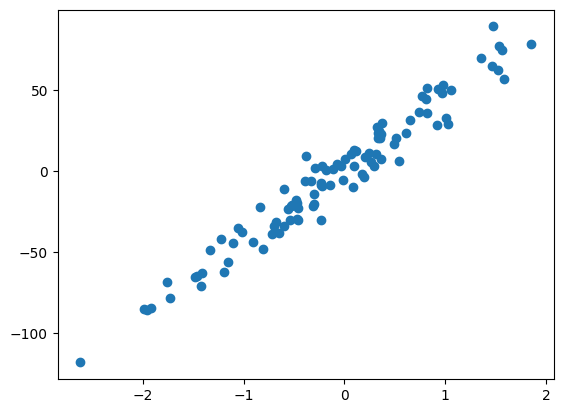

In [14]:
x, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
plt.scatter(x, y)

In [15]:
print(x.shape, y.shape)

(100, 1) (100,)


In [16]:
y = y.reshape(y.shape[0], 1)  # Reshape y to be a column vector

In [17]:
# matrice X
X = np.hstack((x, np.ones(x.shape)))
print(x.shape, y.shape, X.shape)

(100, 1) (100, 1) (100, 2)


In [18]:
theta = np.random.randn(2, 1)  # Random initialization of theta
theta.shape

(2, 1)

In [19]:
def model(X, theta):
    return X.dot(theta)

model(X, theta)

array([[-0.14822364],
       [-0.30354133],
       [-0.51414807],
       [-0.26174218],
       [-0.40771184],
       [-0.20039737],
       [-0.40481303],
       [-0.21973838],
       [-0.20702272],
       [-0.13493094],
       [-0.16834637],
       [-0.03659568],
       [-0.18369649],
       [-0.35996992],
       [-0.46829833],
       [-0.30267413],
       [-0.68008592],
       [-0.22512748],
       [-0.12987777],
       [-0.80152315],
       [-0.22817287],
       [-0.30169597],
       [-0.40523839],
       [-0.15114479],
       [-0.03170065],
       [-0.04991322],
       [-0.43005825],
       [-0.3261469 ],
       [-0.43025472],
       [-0.5396278 ],
       [-0.25385606],
       [-0.2504368 ],
       [-0.27152819],
       [-0.41701838],
       [-0.48660944],
       [-0.28333828],
       [-0.37456565],
       [-0.25302385],
       [-0.16822819],
       [-0.37322013],
       [-0.25306808],
       [-0.44409246],
       [-0.03935654],
       [-0.41490452],
       [-0.36263415],
       [-0

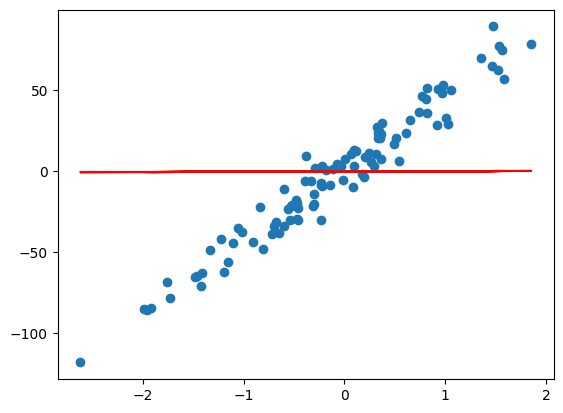

In [20]:
plt.scatter(x, y)
plt.plot(x, model(X, theta), color='red')

In [21]:
def cost_function(X, y, theta):
    m = len(y)
    predictions = model(X, theta)
    cost = (1/(2*m)) * np.sum(np.square(predictions - y))
    return cost

In [22]:
cost_function(X, y, theta)

np.float64(843.3820697428808)

In [23]:
def grad(X, y, theta):
    m = len(y)
    return (1/m) * X.T.dot(model(X, theta) - y)

In [24]:
def gradient_descent(X, y, theta, learning_rate=0.01, iterations=1000):
    cost_history = np.zeros(iterations)
    for i in range(iterations):
        theta -= learning_rate * grad(X, y, theta)
        cost_history[i] = cost_function(X, y, theta)

    return theta, cost_history

In [25]:
theta_final, cost_history = gradient_descent(X, y, theta, learning_rate=0.05, iterations=100)

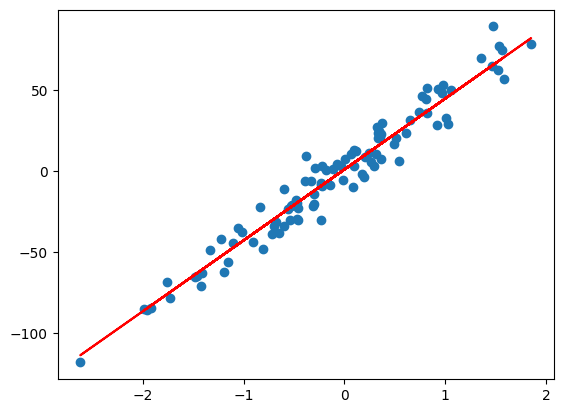

In [26]:
plt.scatter(x, y)
plt.plot(x, model(X, theta_final), color='red')

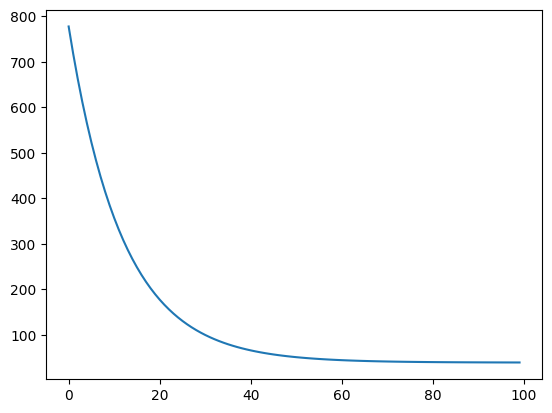

In [27]:
plt.plot(cost_history)

In [28]:
def coef_deter(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - (ss_res / ss_tot)

predictions = model(X, theta_final)
r_squared = coef_deter(y, predictions)
r_squared


np.float64(0.9535499989424576)

In [29]:
cost = cost_function(X, y, theta)
cost

np.float64(39.25976532275506)